# E5 — Customer Segment Profiling

## US-5.1 — Global KPI Baseline

In [1]:
from src.config import *
import numpy as np
np.random.seed(RANDOM_STATE)
import pandas as pd

df_customers = pd.read_csv(DATA_PROCESSED_PATH + "customers_with_clusters.csv")
print(f"Customers: {len(df_customers):,} | Clusters: {df_customers['cluster_id'].nunique()}")

Customers: 64,469 | Clusters: 11


### Compute Global KPI Baseline

In [2]:
from src.profiling import compute_global_kpis

global_kpis = compute_global_kpis(df_customers)

### Global Baseline Table

In [3]:
from src.profiling import NUMERICAL_KPIS
from IPython.display import display # Fix linter issue

def format_kpi(kpi_name: str, value: float) -> str:
    if kpi_name.endswith('_ratio') or kpi_name == 'discount_rate':
        return f"{value:.2%}"
    return f"{value:.2f}"

# Formatted baseline table
baseline_rows = {kpi: format_kpi(kpi, global_kpis.get(kpi, np.nan)) for kpi in NUMERICAL_KPIS}
baseline_df = pd.DataFrame.from_dict(baseline_rows, orient='index', columns=['Global Mean'])
baseline_df.index.name = 'KPI'
display(baseline_df)

,Global Mean
KPI,
monetary_avg,40.20
frequency,3.00
avg_basket_size_eur,69.54
avg_units_per_basket,2.01
recency_days,111.44
store_ratio,88.28%
estore_ratio,11.71%
click_collect_ratio,0.01%
axe_make_up_ratio,-inf%


In [4]:
# Loyalty Status Distribution
loyalty_df = pd.DataFrame.from_dict(
    global_kpis.get('loyalty_distribution', {}), orient='index', columns=['Proportion']
)
if not loyalty_df.empty:
    loyalty_df['Proportion'] = loyalty_df['Proportion'].map(lambda x: f"{x:.2%}")
    loyalty_df.index.name = 'Loyalty Status'
    display(loyalty_df)

,Proportion
Loyalty Status,
BRONZE,66.41%
SILVER,29.62%
GOLD,3.97%


In [5]:
# Total customers & total sales
print(f"Total Customers: {global_kpis['total_customers']:,}")
print(f"Total Sales (EUR): {global_kpis['total_sales_eur']:,.2f}")

Total Customers: 64,469
Total Sales (EUR): 12,773,158.16


In [6]:
## US-5.2 — Per-Cluster KPI Computation

In [7]:
from src.profiling import compute_cluster_kpis

cluster_kpis_df = compute_cluster_kpis(df_customers)
display(cluster_kpis_df)

,n_customers,pct_customers,monetary_avg,frequency,avg_basket_size_eur,avg_units_per_basket,recency_days,store_ratio,estore_ratio,click_collect_ratio,axe_make_up_ratio,axe_skincare_ratio,axe_fragrance_ratio,axe_haircare_ratio,axe_others_ratio,discount_rate,monetary_total
cluster_id,,,,,,,,,,,,,,,,,
-1,325,0.504118,100.827481,8.926154,352.261156,6.486300,110.966154,0.780967,0.207824,0.011209,0.290175,0.187350,0.313899,0.171890,0.027455,0.185507,1400.694892
0,51376,79.691014,36.067026,3.125506,63.766537,2.011672,109.519328,0.961716,0.038303,0.000000,0.439572,0.216769,-inf,0.032567,inf,0.102335,193.164725
1,6473,10.040485,64.012234,2.036305,93.137583,1.702781,124.774139,0.977163,0.022837,0.000000,-inf,0.151082,0.614074,0.020063,inf,0.153836,176.207140
2,4809,7.459399,42.720204,2.769807,76.676285,2.189667,110.516324,0.073492,0.926508,0.000000,0.373765,0.224363,0.321185,0.059793,0.011952,0.193586,209.440838
3,914,1.417736,69.837807,1.553611,88.812878,1.423979,132.929978,0.023536,0.976464,0.000000,-inf,0.147480,0.640273,0.030666,0.001362,0.249750,135.656204
4,447,0.693356,34.520163,3.105145,63.243995,2.097859,110.722595,0.987220,0.012780,0.000000,0.476077,0.226713,0.208596,0.044172,0.044442,0.078923,205.440313
5,68,0.105477,35.998965,3.823529,80.063617,2.445312,83.897059,0.970845,0.029155,0.000000,0.499209,0.207831,0.242385,0.031013,0.019562,0.082186,306.110000
6,31,0.048085,89.859954,1.806452,118.537097,1.439247,123.516129,1.000000,0.000000,0.000000,0.026676,0.057322,0.912796,0.000000,0.003207,0.247436,201.702903
7,7,0.010858,54.975833,2.428571,109.247500,2.154762,67.571429,1.000000,0.000000,0.000000,0.180001,0.216563,0.559912,0.000000,0.043524,0.093963,215.381429


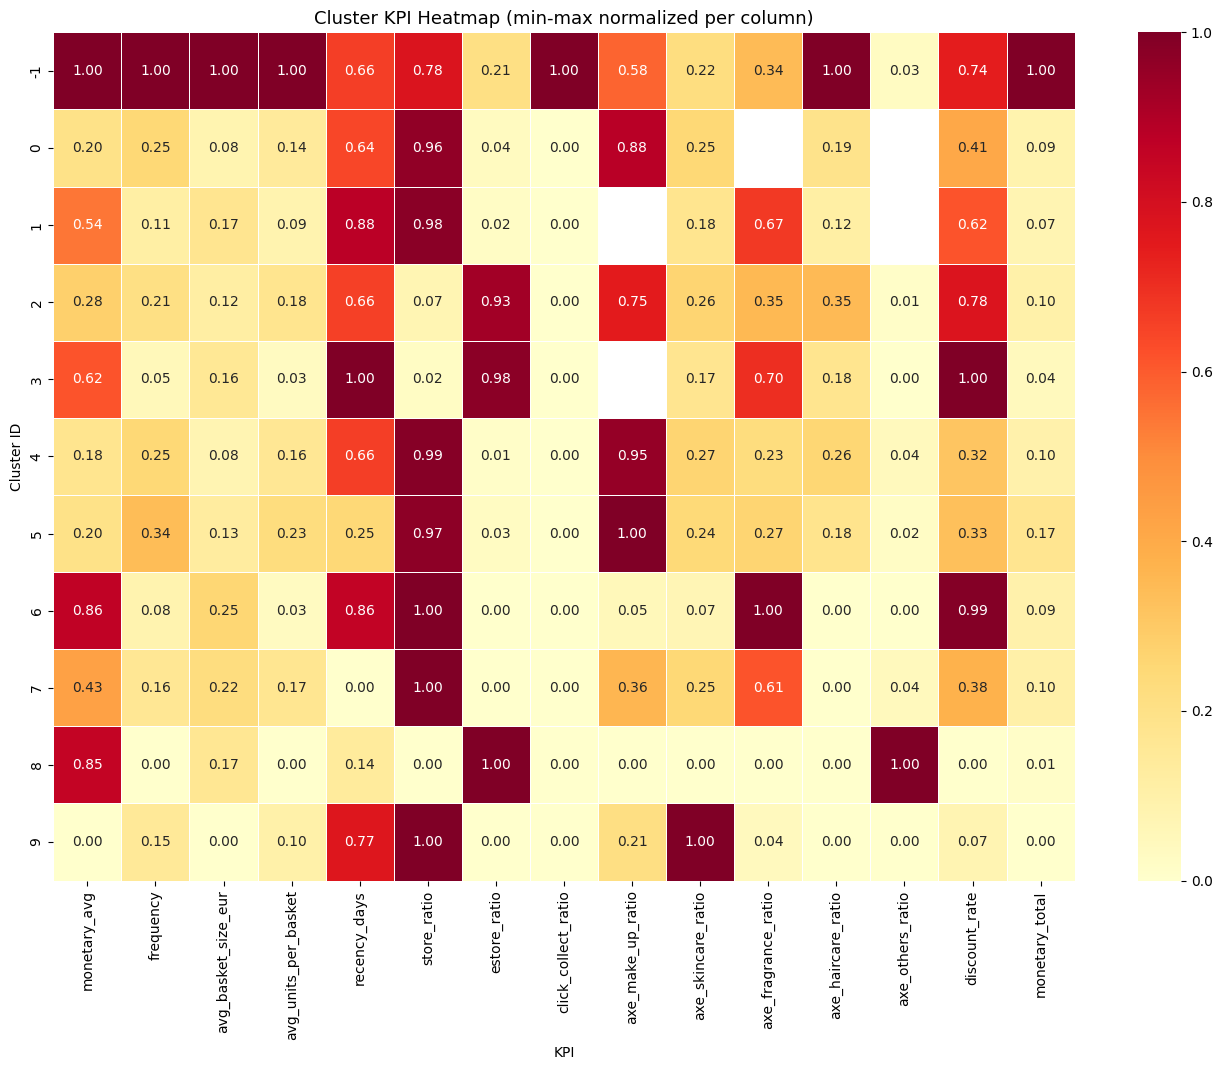

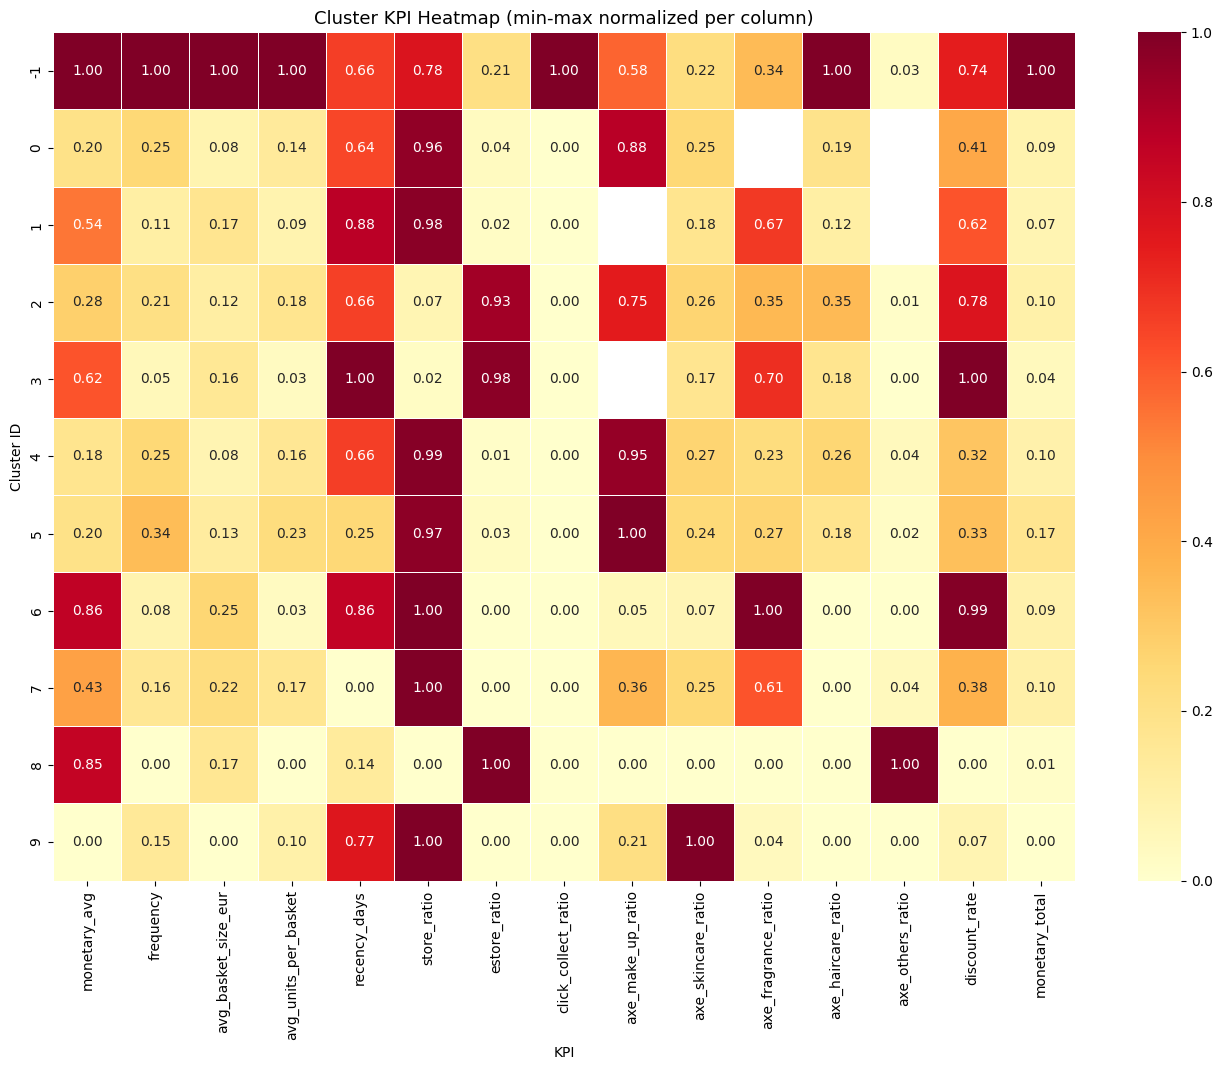

In [8]:
from src.visualization import plot_cluster_kpi_heatmap

fig = plot_cluster_kpi_heatmap(cluster_kpis_df, save_path="figures/cluster_kpi_heatmap.png")
fig

## US-5.3 — Delta Table (Clusters vs. Global Average)

In [9]:
import importlib, src.profiling
importlib.reload(src.profiling)

from src.profiling import build_delta_table, get_notable_deltas, export_delta_table_md
from src.config import OUTPUT_PATH

delta_df = build_delta_table(cluster_kpis_df, global_kpis)
display(delta_df)

/Users/milanviallet/Documents - MacBook Air de Milan/Albert/B2/BDD/Sephora/src/profiling.py:54: RuntimeWarning: invalid value encountered in scalar subtract
  delta_abs = cluster_val - global_val
/Users/milanviallet/Documents - MacBook Air de Milan/Albert/B2/BDD/Sephora/src/profiling.py:55: RuntimeWarning: invalid value encountered in scalar divide
  delta_pct = ((cluster_val / global_val) - 1) * 100 if global_val != 0 else np.nan


,cluster_id,kpi,global_avg,cluster_value,delta_abs,delta_pct
0,-1,avg_basket_size_eur,69.5360,352.2612,282.7252,406.59
1,-1,avg_units_per_basket,2.0088,6.4863,4.4775,222.90
2,-1,axe_fragrance_ratio,-inf,0.3139,inf,-100.00
3,-1,axe_haircare_ratio,0.0341,0.1719,0.1378,404.55
4,-1,axe_make_up_ratio,-inf,0.2902,inf,-100.00
...,...,...,...,...,...,...
160,9,frequency,2.9960,2.3333,-0.6626,-22.12
161,9,monetary_avg,40.2007,20.0726,-20.1281,-50.07
162,9,monetary_total,198.1287,77.3433,-120.7854,-60.96
163,9,recency_days,111.4422,117.6667,6.2245,5.59


### Color-Coded Delta Table

In [10]:
# Pivot to wide format for display: rows = clusters, columns = KPIs, values = delta_pct
delta_wide = delta_df.pivot(index='cluster_id', columns='kpi', values='delta_pct')

# Color-coded display: green = above average, red = below average
styled = delta_wide.style.background_gradient(
    cmap='RdYlGn', axis=None, vmin=-100, vmax=100
).format("{:.1f}%").set_caption("Delta % vs. Global Average (green = above, red = below)")
styled

kpi,avg_basket_size_eur,avg_units_per_basket,axe_fragrance_ratio,axe_haircare_ratio,axe_make_up_ratio,axe_others_ratio,axe_skincare_ratio,click_collect_ratio,discount_rate,estore_ratio,frequency,monetary_avg,monetary_total,recency_days,store_ratio
cluster_id,,,,,,,,,,,,,,,
-1,406.6%,222.9%,-100.0%,404.6%,-100.0%,-100.0%,-10.6%,19736.6%,59.0%,77.4%,197.9%,150.8%,607.0%,-0.4%,-11.5%
5,15.1%,21.7%,-100.0%,-9.0%,-100.0%,-100.0%,-0.8%,-100.0%,-29.6%,-75.1%,27.6%,-10.4%,54.5%,-24.7%,10.0%
7,57.1%,7.3%,-100.0%,-100.0%,-100.0%,-100.0%,3.3%,-100.0%,-19.5%,-100.0%,-18.9%,36.8%,8.7%,-39.4%,13.3%
2,10.3%,9.0%,-100.0%,75.5%,-100.0%,-100.0%,7.0%,-100.0%,65.9%,690.9%,-7.5%,6.3%,5.7%,-0.8%,-91.7%
4,-9.1%,4.4%,-100.0%,29.7%,-100.0%,-100.0%,8.2%,-100.0%,-32.4%,-89.1%,3.6%,-14.1%,3.7%,-0.7%,11.8%
6,70.5%,-28.4%,-100.0%,-100.0%,-100.0%,-100.0%,-72.7%,-100.0%,112.1%,-100.0%,-39.7%,123.5%,1.8%,10.8%,13.3%
0,-8.3%,0.1%,nan%,-4.4%,-100.0%,nan%,3.4%,-100.0%,-12.3%,-67.3%,4.3%,-10.3%,-2.5%,-1.7%,8.9%
1,33.9%,-15.2%,-100.0%,-41.1%,nan%,nan%,-27.9%,-100.0%,31.9%,-80.5%,-32.0%,59.2%,-11.1%,12.0%,10.7%
3,27.7%,-29.1%,-100.0%,-10.0%,nan%,-100.0%,-29.6%,-100.0%,114.0%,733.6%,-48.1%,73.7%,-31.5%,19.3%,-97.3%


### Notable Deltas (|Δ%| > 30%)

In [11]:
notable = get_notable_deltas(delta_df)

if notable.empty:
    print("No notable deltas (|Δ%| > 30%) found.")
else:
    print(f"{len(notable)} notable deviations found:\n")
    for _, r in notable.iterrows():
        direction = "above" if r['delta_pct'] > 0 else "below"
        print(f"  Cluster {r['cluster_id']} — {r['kpi']}: {r['delta_pct']:+.1f}% {direction} global avg")

98 notable deviations found:

  Cluster -1 — avg_basket_size_eur: +406.6% above global avg
  Cluster -1 — avg_units_per_basket: +222.9% above global avg
  Cluster -1 — axe_fragrance_ratio: -100.0% below global avg
  Cluster -1 — axe_haircare_ratio: +404.6% above global avg
  Cluster -1 — axe_make_up_ratio: -100.0% below global avg
  Cluster -1 — axe_others_ratio: -100.0% below global avg
  Cluster -1 — click_collect_ratio: +19736.6% above global avg
  Cluster -1 — discount_rate: +59.0% above global avg
  Cluster -1 — estore_ratio: +77.4% above global avg
  Cluster -1 — frequency: +197.9% above global avg
  Cluster -1 — monetary_avg: +150.8% above global avg
  Cluster -1 — monetary_total: +607.0% above global avg
  Cluster 5 — axe_fragrance_ratio: -100.0% below global avg
  Cluster 5 — axe_make_up_ratio: -100.0% below global avg
  Cluster 5 — axe_others_ratio: -100.0% below global avg
  Cluster 5 — click_collect_ratio: -100.0% below global avg
  Cluster 5 — estore_ratio: -75.1% below gl

### Export Delta Table

In [12]:
export_path = OUTPUT_PATH + "kpi_delta_table.md"
export_delta_table_md(delta_df, export_path)
print(f"Delta table exported to {export_path}")

Delta table exported to _bmad-output/implementation-artifacts/kpi_delta_table.md


In [13]:
import importlib, src.visualization
importlib.reload(src.visualization)
print("visualization module reloaded")

visualization module reloaded


## US 5.4 — Top Distinguishing Features per Cluster (Cohen's d)

In [14]:
from src.profiling import compute_distinguishing_features
from src.visualization import plot_distinguishing_features
from IPython.display import display

# Compute Cohen's d per cluster
features = [k for k in NUMERICAL_KPIS if k in df_customers.columns]
distinguishing_features = compute_distinguishing_features(df_customers, features)

# Display top 5 features per cluster
for cluster_id in sorted(distinguishing_features.keys()):
    top5 = distinguishing_features[cluster_id].head(5)
    print(f"\n--- Cluster {cluster_id} — Top 5 Distinguishing Features ---")
    display(top5[['feature', 'cohens_d']])


--- Cluster -1 — Top 5 Distinguishing Features ---


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _e

,feature,cohens_d
0,axe_make_up_ratio,inf
1,axe_fragrance_ratio,inf
2,axe_others_ratio,-inf
3,click_collect_ratio,1.120879e+08
4,avg_basket_size_eur,5.019538e+00



--- Cluster 0 — Top 5 Distinguishing Features ---


,feature,cohens_d
0,axe_make_up_ratio,inf
1,axe_fragrance_ratio,-inf
2,store_ratio,0.831917
3,estore_ratio,-0.831394
4,monetary_avg,-0.468599


...

,feature,cohens_d
0,axe_make_up_ratio,inf
1,axe_fragrance_ratio,inf
2,axe_others_ratio,-inf
3,avg_basket_size_eur,0.611689
4,monetary_avg,0.451143



--- Cluster 8 — Top 5 Distinguishing Features ---


,feature,cohens_d
0,axe_make_up_ratio,inf
1,axe_fragrance_ratio,inf
2,axe_others_ratio,-inf
3,estore_ratio,3.145924
4,store_ratio,-3.145074



--- Cluster 9 — Top 5 Distinguishing Features ---


,feature,cohens_d
0,axe_make_up_ratio,inf
1,axe_fragrance_ratio,inf
2,axe_others_ratio,-inf
3,axe_skincare_ratio,1.761150
4,discount_rate,-0.649984


11 figures saved to figures/


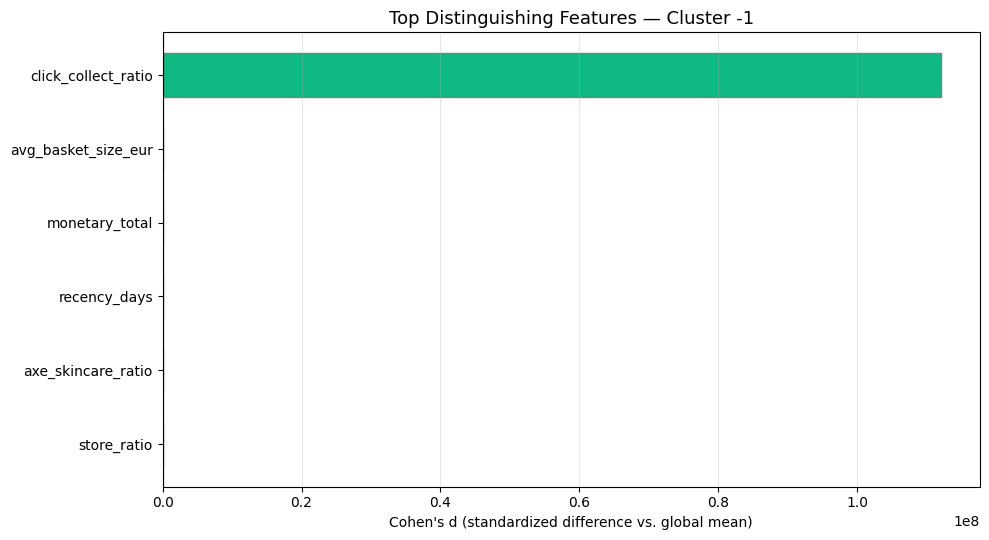

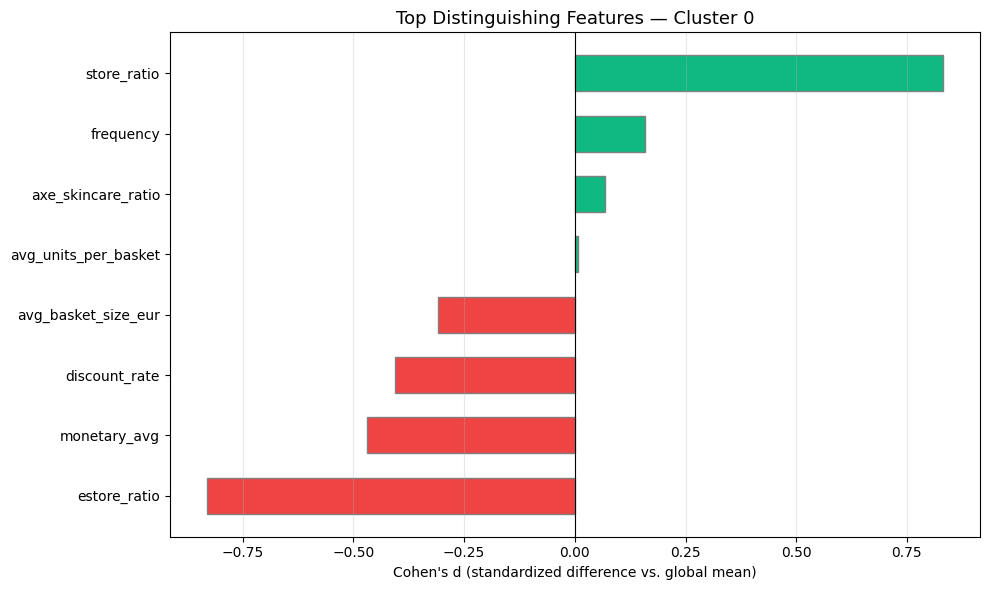

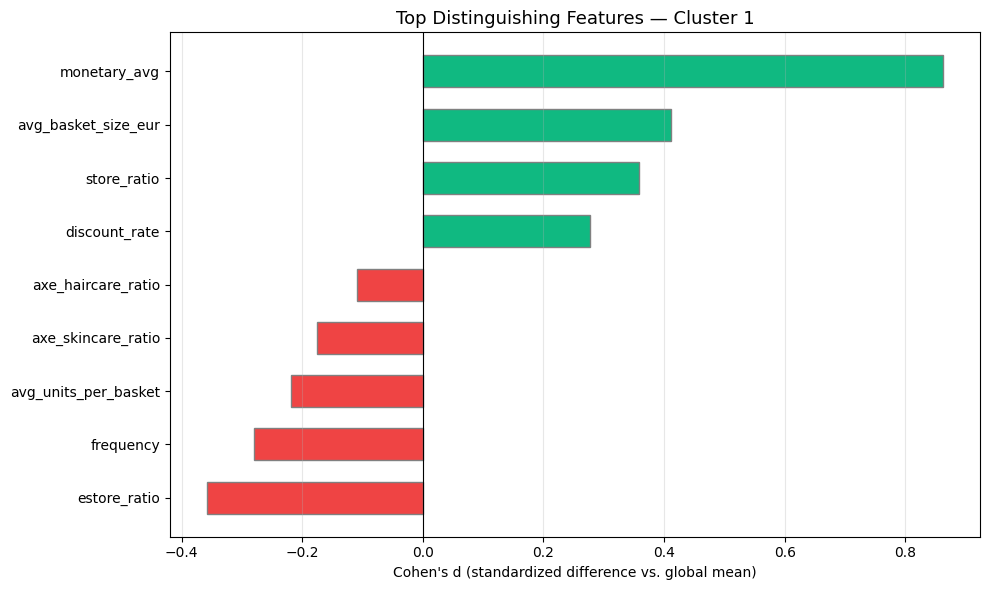

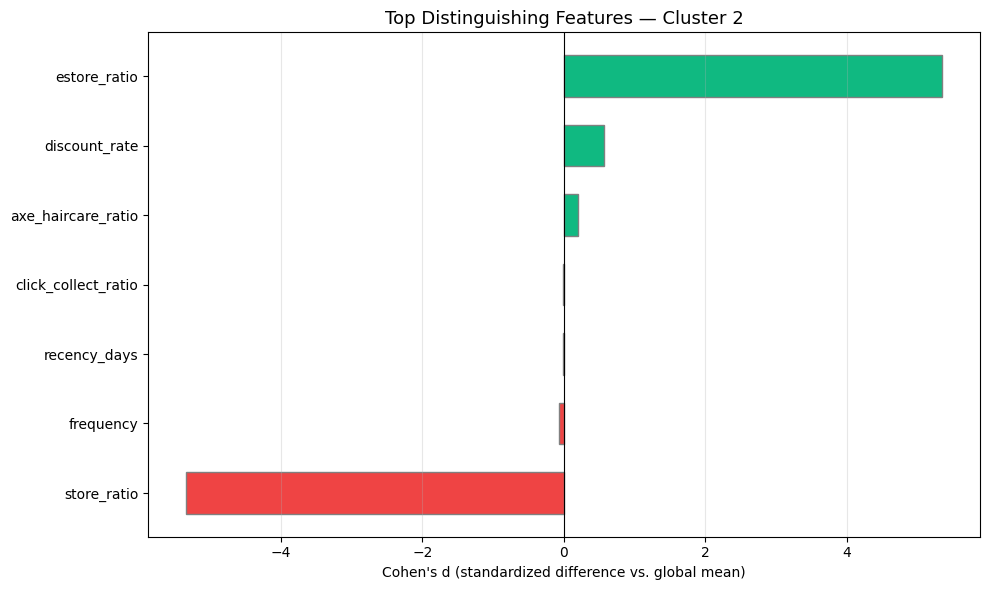

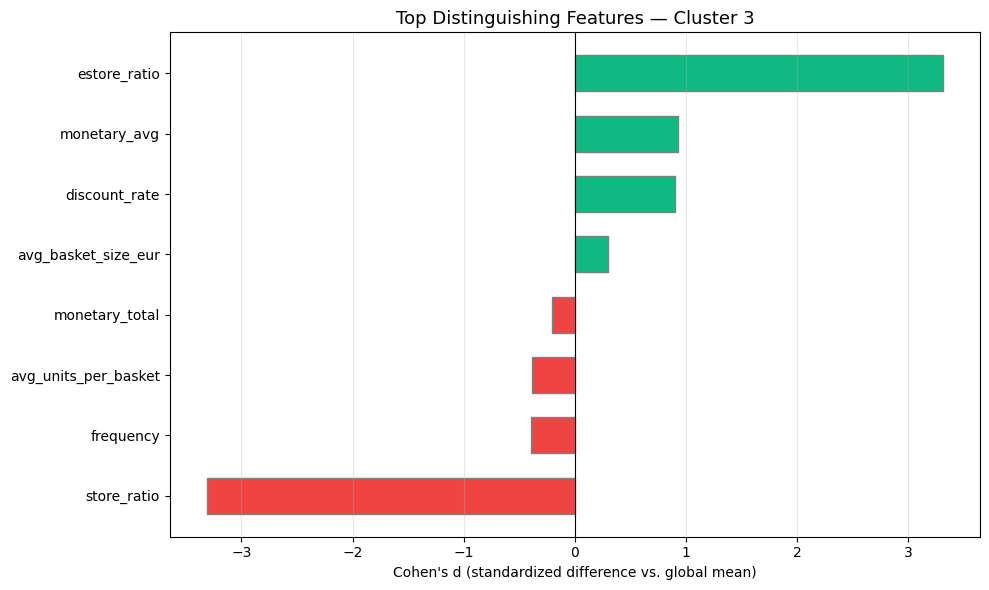

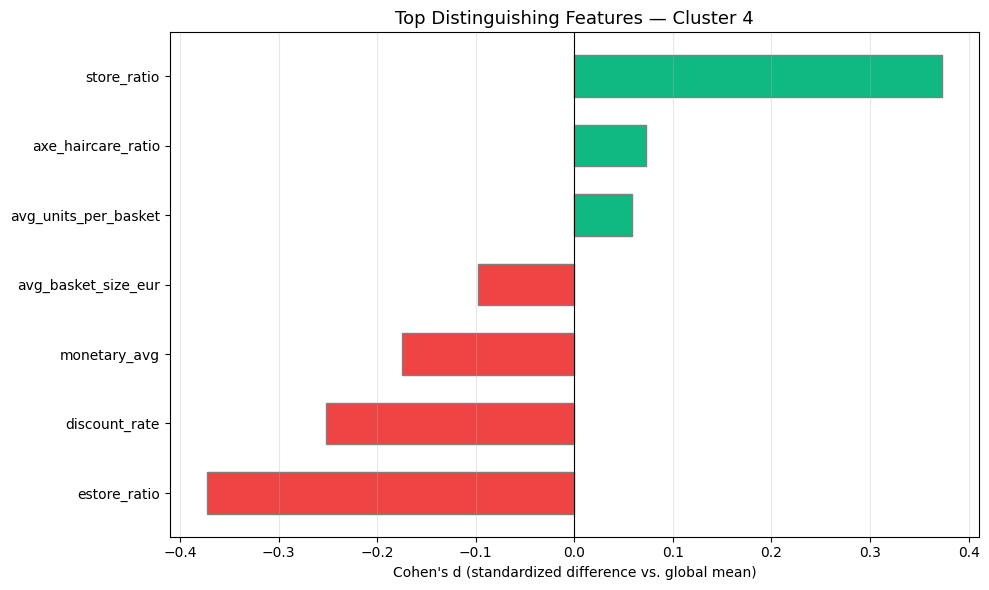

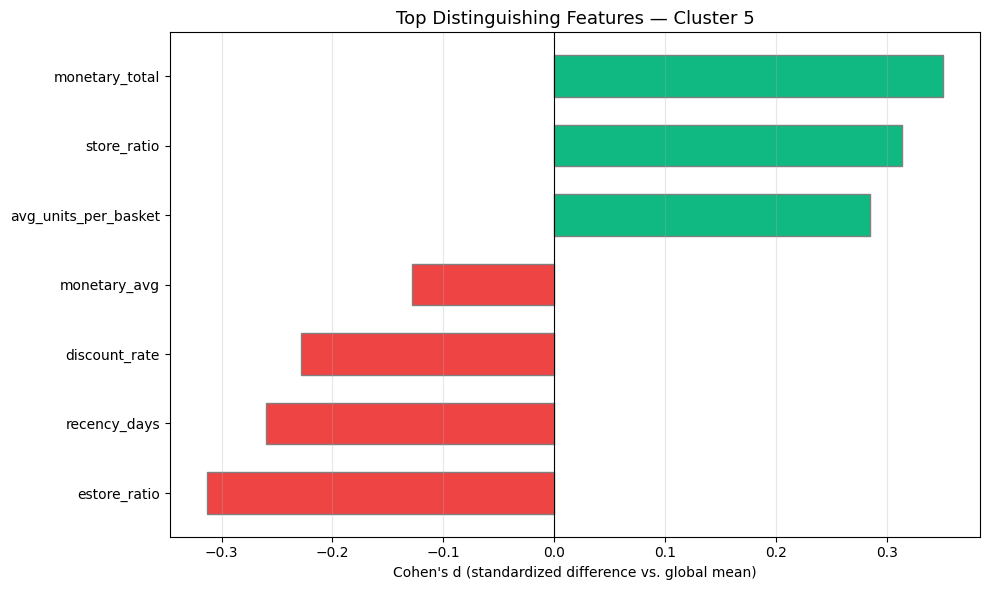

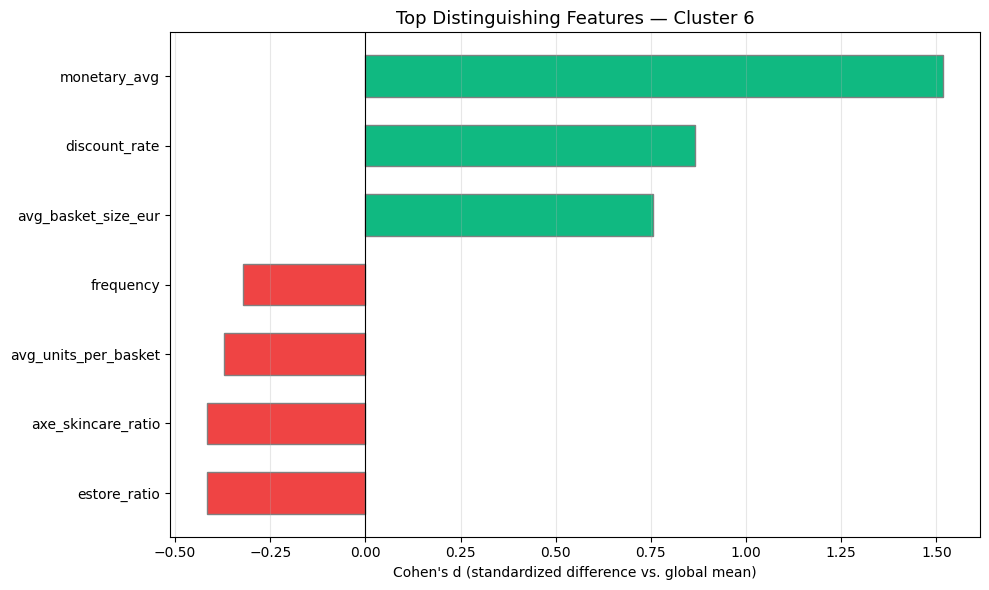

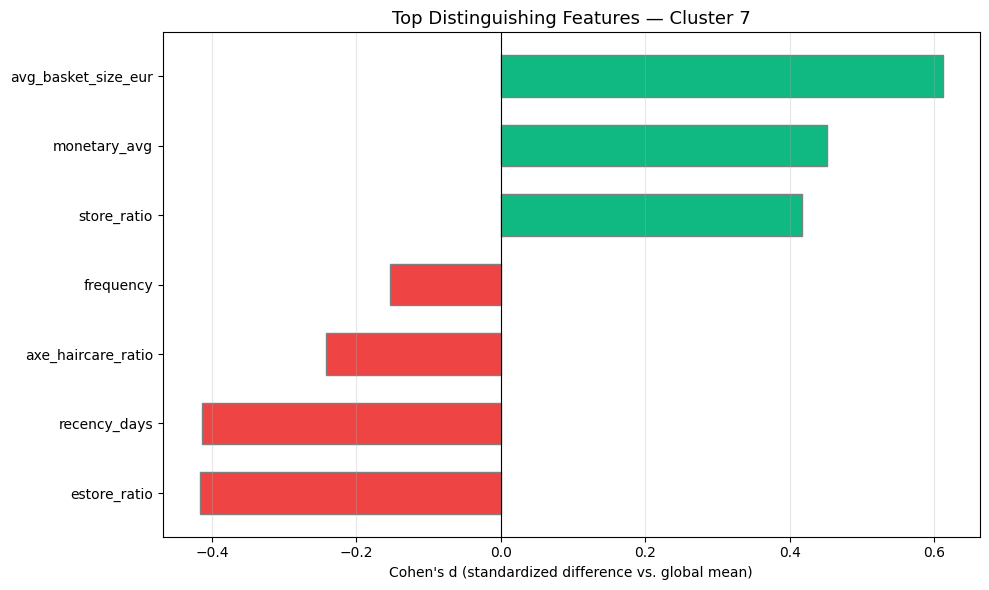

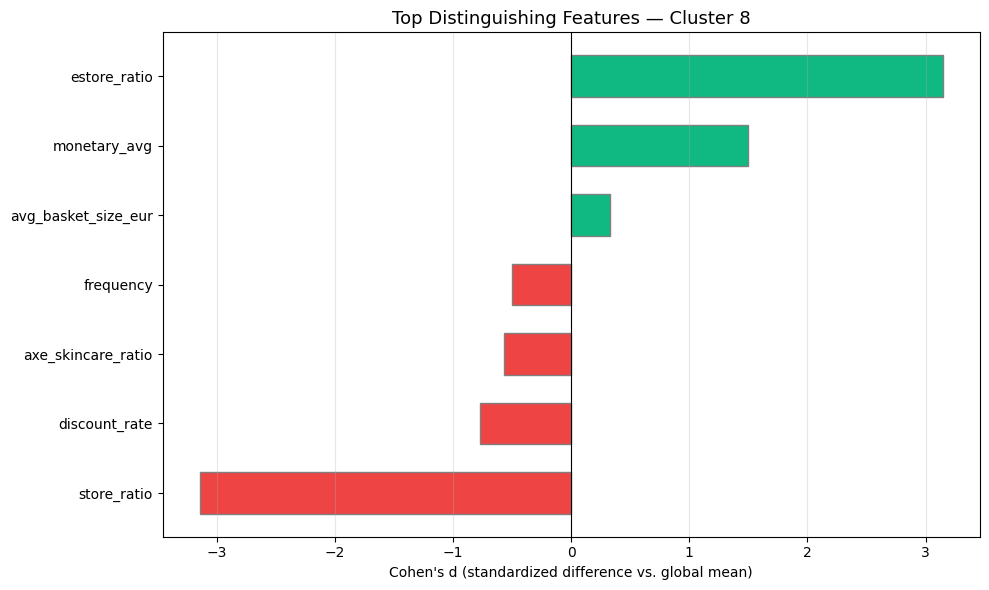

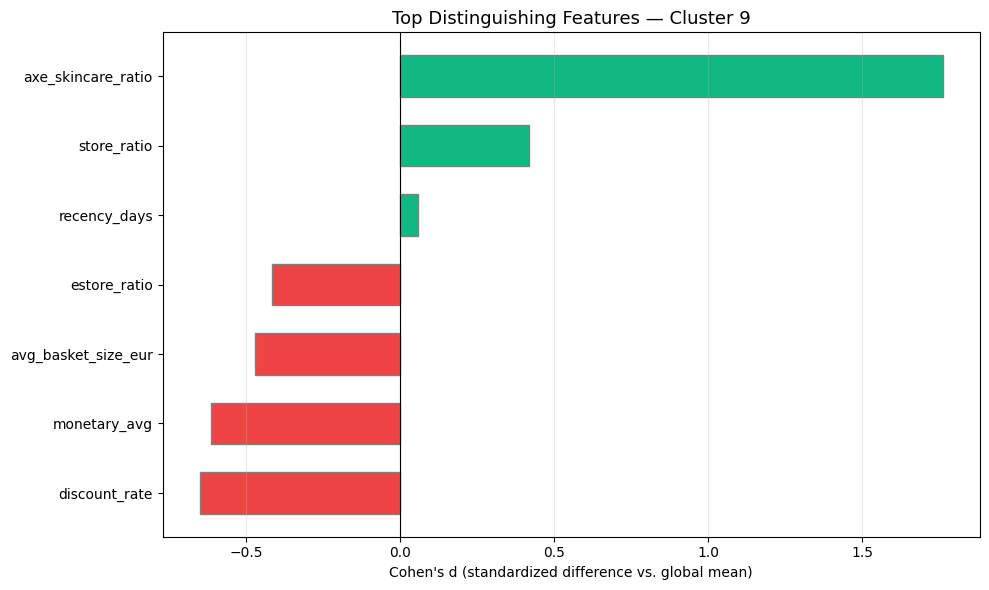

In [15]:
# Bar charts — top distinguishing features per cluster
figs = plot_distinguishing_features(distinguishing_features, top_n=5, save_dir="figures")
print(f"{len(figs)} figures saved to figures/")

import importlib, src.validation
importlib.reload(src.validation)

from src.validation import run_kruskal_wallis, run_posthoc_mannwhitney, print_kruskal_summary
from src.profiling import NUMERICAL_KPIS
from IPython.display import display

# Select KPIs present in df_customers (max 10 as per AC)
kpis_for_test = [k for k in NUMERICAL_KPIS if k in df_customers.columns][:10]
print(f"Testing {len(kpis_for_test)} KPIs: {kpis_for_test}")

# Kruskal-Wallis test
kw_results = run_kruskal_wallis(df_customers, kpis_for_test)
display(kw_results)

# Summary
print_kruskal_summary(kw_results, len(kpis_for_test))

n_significant = kw_results['significant'].sum()
assert n_significant >= 7, f"Only {n_significant}/{len(kpis_for_test)} KPIs are significant — consider revisiting clustering"

In [16]:
import importlib, src.validation
importlib.reload(src.validation)

from src.validation import run_kruskal_wallis, run_posthoc_mannwhitney, print_kruskal_summary
from src.profiling import NUMERICAL_KPIS
from IPython.display import display

# Select KPIs present in df_customers (max 10 as per AC)
kpis_for_test = [k for k in NUMERICAL_KPIS if k in df_customers.columns][:10]
print(f"Testing {len(kpis_for_test)} KPIs: {kpis_for_test}")

# Kruskal-Wallis test
kw_results = run_kruskal_wallis(df_customers, kpis_for_test)
display(kw_results)

# Summary
print_kruskal_summary(kw_results, len(kpis_for_test))

Testing 10 KPIs: ['monetary_avg', 'frequency', 'avg_basket_size_eur', 'avg_units_per_basket', 'recency_days', 'store_ratio', 'estore_ratio', 'click_collect_ratio', 'axe_make_up_ratio', 'axe_skincare_ratio']


,kpi,H_statistic,p_value,significant
0,monetary_avg,4341.492,0.000000e+00,True
1,frequency,1527.443,0.000000e+00,True
2,avg_basket_size_eur,2998.178,0.000000e+00,True
3,avg_units_per_basket,1233.786,7.416938e-259,True
4,recency_days,179.122,3.564558e-33,True
5,store_ratio,32823.719,0.000000e+00,True
6,estore_ratio,32822.482,0.000000e+00,True
7,click_collect_ratio,986.892,1.245661e-205,True
8,axe_make_up_ratio,3632.269,0.000000e+00,True
9,axe_skincare_ratio,943.732,2.454325e-196,True


Statistical validation: 10/10 KPIs significantly differ across segments at p < 0.05


'Statistical validation: 10/10 KPIs significantly differ across segments at p < 0.05'

In [17]:
# Post-hoc Mann-Whitney U pairwise tests for significant KPIs
sig_kpis = kw_results.loc[kw_results['significant'], 'kpi'].tolist()
print(f"\nPost-hoc pairwise Mann-Whitney U for {len(sig_kpis)} significant KPIs")

posthoc_results = run_posthoc_mannwhitney(df_customers, sig_kpis)

# Show only significant pairs
sig_pairs = posthoc_results[posthoc_results['significant']]
print(f"  → {len(sig_pairs)} significant pairs out of {len(posthoc_results)} total")
display(sig_pairs)


Post-hoc pairwise Mann-Whitney U for 10 significant KPIs
  → 307 significant pairs out of 550 total


,kpi,cluster_a,cluster_b,U_statistic,p_value,significant
0,monetary_avg,-1,0,11687058.5,1.452994e-35,True
2,monetary_avg,-1,2,1014973.0,1.726649e-19,True
4,monetary_avg,-1,4,102467.0,1.828344e-22,True
5,monetary_avg,-1,5,15158.0,1.421490e-06,True
6,monetary_avg,-1,6,3475.5,4.342095e-03,True
...,...,...,...,...,...,...
545,axe_skincare_ratio,6,8,253.5,4.889218e-02,True
546,axe_skincare_ratio,6,9,2.0,1.864171e-05,True
547,axe_skincare_ratio,7,8,65.0,1.543914e-02,True
548,axe_skincare_ratio,7,9,2.0,6.555903e-03,True


## US-5.6 — CLV Ranking &amp; High-Potential Segment Identification

In [18]:
import importlib, src.profiling, src.visualization
importlib.reload(src.profiling)
importlib.reload(src.visualization)

from src.profiling import rank_by_clv, identify_high_potential_segments
from src.visualization import plot_priority_matrix
from IPython.display import display

# Rank clusters by CLV
ranked_clusters_df = rank_by_clv(cluster_kpis_df)
print("=== CLV Ranking (all segments, sorted by monetary_total desc) ===")
display(ranked_clusters_df[['n_customers', 'pct_customers', 'monetary_total', 'clv_tier']])

=== CLV Ranking (all segments, sorted by monetary_total desc) ===


,n_customers,pct_customers,monetary_total,clv_tier
cluster_id,,,,
-1,325,0.504118,1400.694892,Top
5,68,0.105477,306.110000,Top
7,7,0.010858,215.381429,Top
2,4809,7.459399,209.440838,Top
4,447,0.693356,205.440313,Mid
6,31,0.048085,201.702903,Mid
0,51376,79.691014,193.164725,Mid
1,6473,10.040485,176.207140,Low
3,914,1.417736,135.656204,Low


In [19]:
# Identify high-potential and investment-worthy segments
segments = identify_high_potential_segments(cluster_kpis_df)

print("=== Top 3 Priority Segments (by CLV) ===")
for i, cid in enumerate(segments['top3_priority'], 1):
    row = cluster_kpis_df.loc[cid]
    print(f"  {i}. Cluster {cid} — CLV={row['monetary_total']:.0f}€, Size={row['pct_customers']:.1f}%")

print(f"\n=== High-Potential Segments (above-median size AND CLV) ===")
print(f"  Clusters: {segments['high_potential']}")

print(f"\n=== Investment-Worthy Segments (high CLV, small size → loyalty upgrade) ===")
print(f"  Clusters: {segments['investment_worthy']}")

=== Top 3 Priority Segments (by CLV) ===
  1. Cluster -1 — CLV=1401€, Size=0.5%
  2. Cluster 5 — CLV=306€, Size=0.1%
  3. Cluster 7 — CLV=215€, Size=0.0%

=== High-Potential Segments (above-median size AND CLV) ===
  Clusters: [-1, 2, 4]

=== Investment-Worthy Segments (high CLV, small size → loyalty upgrade) ===
  Clusters: [5, 6, 7]


Saved: figures/priority_matrix.png


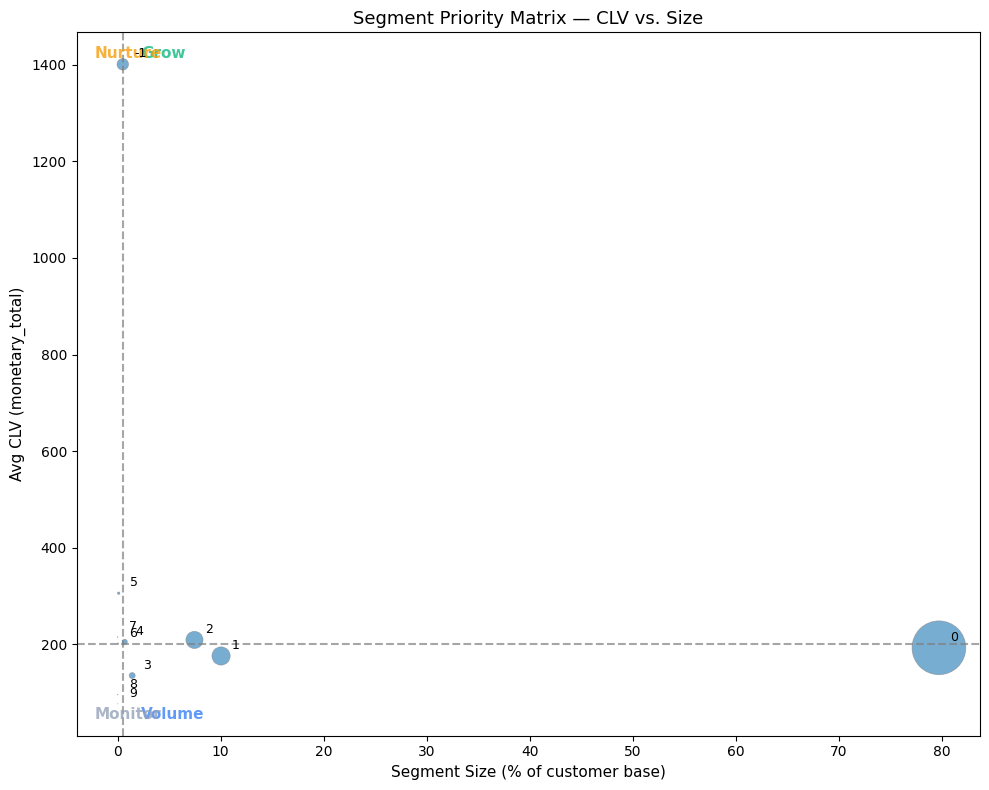

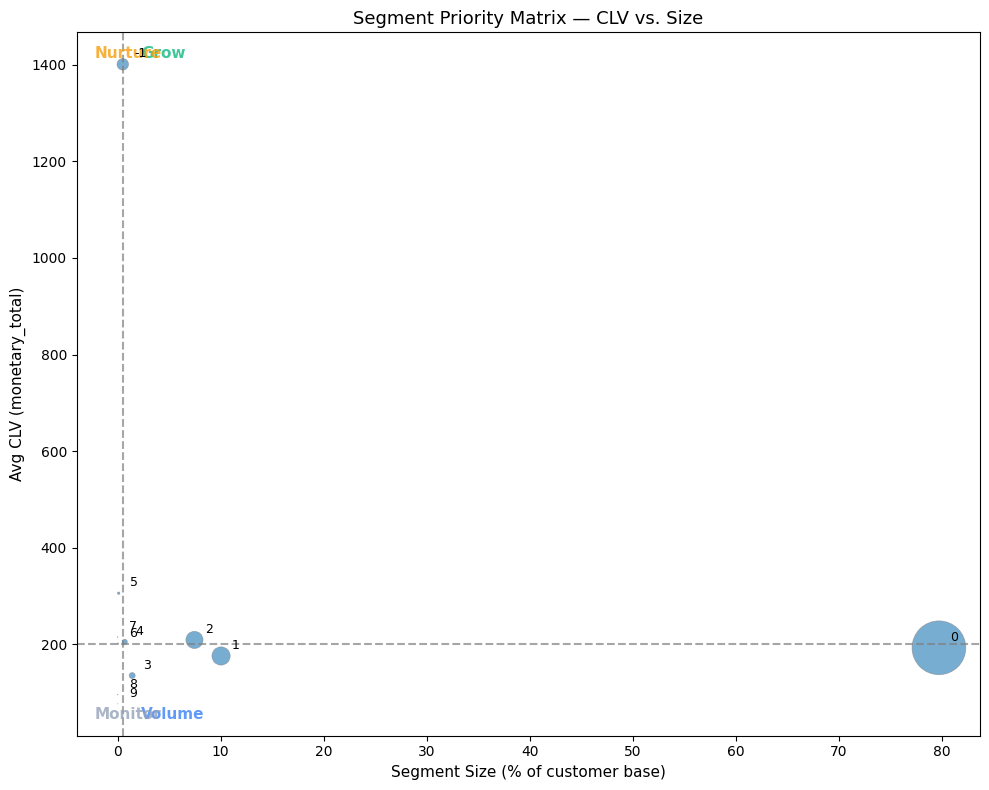

In [20]:
# Priority matrix visualization
fig = plot_priority_matrix(cluster_kpis_df, save_path="figures/priority_matrix.png")
print("Saved: figures/priority_matrix.png")
fig

### E5 Gate — Profiling Complete

All segments have been ranked by CLV with tier assignments (Top / Mid / Low).  
High-potential and investment-worthy segments identified.  
Priority matrix saved to `figures/priority_matrix.png`.

**Profiling complete — proceeding to E6 Personas.**